<a href="https://colab.research.google.com/github/IronZiiz/Domain-specific_finetunning/blob/main/Phase2_Generalization_data_agumentation_effects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2 — K-Fold Cross-Validation

**Objective:** Validate the configuration selected in Phase 1 via 5-fold cross-validation, comparing the effect of data augmentation on the model's generalization.

**Selected configuration (from Phase 1):**
```python
n_epochs = 100
learning_rate = 1e-5
weight_decay = 0.1
batch_size = 1
```

**Cross-validation:** 5-fold K-Fold (shuffle=True, random_state=42), applied to all 26 images

**Total models trained:** 1 configs × 5 folds = 5 models

**Inference parameters:**
- `diameter = None` (auto-detection)
- `channel_axis = -1`
- All others: Cellpose defaults

**Data Augmentation Pipeline (only on training within each fold):**
- HorizontalFlip (p=0.5)
- VerticalFlip (p=0.5)
- RandomRotate90 (p=0.5)
- Affine: scale=[0.95, 1.05], rotate=[-20, 20] (p=0.5)
- RandomBrightnessContrast: ±10% (p=0.3)
- ElasticTransform: α=20, σ=5 (p=0.15)

**Output artifacts:** model checkpoints (.pth), aggregated metrics, per-image metrics, train loss curves

## 0. Environment Setup

In [ ]:
!pip install --quiet cellpose
!pip install --quiet albumentations

print("Install complete. RESTART RUNTIME if first run (Runtime > Restart session).")

Install complete. RESTART RUNTIME if first run (Runtime > Restart session).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import time
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import cv2

from sklearn.model_selection import KFold

import albumentations as A

from cellpose import models, train, io
from cellpose.metrics import average_precision

import cellpose
print(f"Cellpose: {cellpose.version}")
print(f"Torch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Cellpose: 4.2.1.1
Torch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


## 1. Configuration



### ⚠️ IMPORTANT: External Data Requirement

To use this notebook, you must provide your own histology dataset. If you do not have access, please request it from the research team.

**Required Directory Structure:**
Place your data in a folder named `./dataset/` with `train` and `test` subdirectories containing your `.tif` images and corresponding `_masks.tif`

In [1]:
import os
from pathlib import Path
import numpy as np
import torch


# Generic paths for accessibility
DATA_BASE_PATH = Path("./dataset")
TRAIN_DATA_PATH = DATA_BASE_PATH / "train"
TEST_DATA_PATH = DATA_BASE_PATH / "test"

# Output directory for models and metrics
OUTPUT_DIR = Path("./phase2_kfold_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_DIRS = {
    "A_no_augmentation": OUTPUT_DIR / "A_no_augmentation",
    "B_with_augmentation": OUTPUT_DIR / "B_with_augmentation",
}

for d in EXPERIMENT_DIRS.values():
    (d / "models").mkdir(parents=True, exist_ok=True)
    (d / "metrics").mkdir(parents=True, exist_ok=True)
    (d / "per_image_metrics").mkdir(parents=True, exist_ok=True)

# Configuration parameters
N_EPOCHS = 100
LEARNING_RATE = 0.00001
WEIGHT_DECAY = 0.1
BATCH_SIZE = 1
AUGMENTATION_MULTIPLIER = 2
K_FOLDS = 5
RANDOM_SEED = 42
IOU_THRESHOLDS = [0.5, 0.75, 0.9]

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f"Results will be saved in: {OUTPUT_DIR.absolute()}")
if not DATA_BASE_PATH.exists():
    print(f"WARNING: Data directory '{DATA_BASE_PATH}' not found. Please ensure your dataset is placed correctly.")

KeyboardInterrupt: 

## 2. Data Loading

In [ ]:
def load_image_and_mask(img_path, mask_path):
    img = io.imread(str(img_path))
    if img.ndim == 3 and img.shape[-1] == 4:
        img = img[:, :, :3]
    mask = io.imread(str(mask_path))
    return img, mask


def load_dataset(folder_path):
    folder = Path(folder_path)
    img_files = sorted([
        f for f in folder.glob("*")
        if f.suffix.lower() in [".tif", ".tiff", ".png", ".jpg"]
        and "_mask" not in f.stem
        and "_masks" not in f.stem
        and "_seg" not in f.stem
    ])

    images, masks, names = [], [], []
    for img_file in img_files:
        possible_mask_paths = [
            folder / f"{img_file.stem}_masks.tif",
            folder / f"{img_file.stem}_masks.png",
            folder / f"{img_file.stem}_mask.tif",
            folder / f"{img_file.stem}_seg.npy",
        ]

        mask_path = None
        for p in possible_mask_paths:
            if p.exists():
                mask_path = p
                break

        if mask_path is None:
            print(f"WARNING: no mask for {img_file.name}")
            continue

        if mask_path.suffix == ".npy":
            seg_data = np.load(str(mask_path), allow_pickle=True).item()
            mask = seg_data["masks"]
            img = io.imread(str(img_file))
            if img.ndim == 3 and img.shape[-1] == 4:
                img = img[:, :, :3]
        else:
            img, mask = load_image_and_mask(img_file, mask_path)

        images.append(img)
        masks.append(mask)
        names.append(img_file.stem)

    return images, masks, names


train_images, train_masks, train_names = load_dataset(TRAIN_DATA_PATH)
test_images, test_masks, test_names = load_dataset(TEST_DATA_PATH)

all_images = train_images + test_images
all_masks = train_masks + test_masks
all_names = train_names + test_names

print(f"Train (original): {len(train_images)}")
print(f"Test (original): {len(test_images)}")
print(f"Total combined: {len(all_images)} images")
print(f"\nAll images: {all_names}")

Train (original): 21
Test (original): 5
Total combined: 26 images

All images: ['11', '12', '13', '14', '16', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '3', '4', '5', '6', '8', '9', '1', '10', '15', '17', '7']


## 3. Data Augmentation Function

In [ ]:
def get_augmentation_pipeline():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.Affine(
            scale=(0.95, 1.05),
            rotate=(-20, 20),
            border_mode=cv2.BORDER_REFLECT_101,
            p=0.5
        ),
        A.RandomBrightnessContrast(
            brightness_limit=0.1,
            contrast_limit=0.1,
            p=0.3
        ),
        A.ElasticTransform(
            alpha=20,
            sigma=5,
            p=0.15
        )
    ])


def augment_data(train_data, train_labels, augmentation_multiplier=2):
    transform = get_augmentation_pipeline()

    augmented_images = []
    augmented_masks = []

    for img, mask in zip(train_data, train_labels):
        augmented_images.append(img)
        augmented_masks.append(mask)

        for _ in range(augmentation_multiplier):
            augmented = transform(image=img, mask=mask)
            augmented_images.append(augmented['image'])
            augmented_masks.append(augmented['mask'])

    return augmented_images, augmented_masks


print("Augmentation function ready.")

Augmentation function ready.


## 4. Metrics Functions

In [ ]:
def compute_metrics_at_threshold(test_labels, predicted_masks, threshold):
    ap, tp, fp, fn = average_precision(
        test_labels,
        predicted_masks,
        threshold=[threshold]
    )

    ap_per_image = ap.flatten().tolist()
    tp_per_image = tp.flatten().astype(int).tolist()
    fp_per_image = fp.flatten().astype(int).tolist()
    fn_per_image = fn.flatten().astype(int).tolist()

    total_tp = int(np.sum(tp))
    total_fp = int(np.sum(fp))
    total_fn = int(np.sum(fn))

    mean_ap = float(np.mean(ap))

    precision = total_tp / (total_tp + total_fp + 1e-8)
    recall = total_tp / (total_tp + total_fn + 1e-8)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

    precision_per_image = [t / (t + f + 1e-8) for t, f in zip(tp_per_image, fp_per_image)]
    recall_per_image = [t / (t + f + 1e-8) for t, f in zip(tp_per_image, fn_per_image)]
    f1_per_image = [2*(p*r)/(p+r+1e-8) for p, r in zip(precision_per_image, recall_per_image)]

    return {
        "aggregate": {
            "AP": mean_ap, "TP": total_tp, "FP": total_fp, "FN": total_fn,
            "Precision": float(precision), "Recall": float(recall), "F1": float(f1),
        },
        "per_image": {
            "AP": ap_per_image, "TP": tp_per_image, "FP": fp_per_image, "FN": fn_per_image,
            "Precision": precision_per_image, "Recall": recall_per_image, "F1": f1_per_image,
        }
    }


def evaluate_model(model, test_data, test_labels, test_names_list):
    predicted_masks = []
    inference_times = []

    for img in test_data:
        t0 = time.time()
        masks_pred, _, _ = model.eval(
            img,
            diameter=None,
            channel_axis=-1
        )
        inference_times.append(time.time() - t0)
        predicted_masks.append(masks_pred)

    results = {
        "thresholds": {},
        "per_image_thresholds": {},
        "inference_time_s": inference_times,
        "test_image_names": test_names_list,
    }

    for thr in IOU_THRESHOLDS:
        metrics = compute_metrics_at_threshold(test_labels, predicted_masks, thr)
        results["thresholds"][f"AP@{thr}"] = metrics["aggregate"]
        results["per_image_thresholds"][f"AP@{thr}"] = metrics["per_image"]

    return results


def free_gpu_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## 5. K-Fold Training Function

In [ ]:
def train_kfold_experiment(
    experiment_name,
    use_augmentation,
    all_images,
    all_masks,
    all_names,
    experiment_dir,
):
    print(f"\n{'#'*70}")
    print(f"# EXPERIMENT: {experiment_name}")
    print(f"# Augmentation: {use_augmentation}")
    print(f"# Config: n_epochs={N_EPOCHS}, lr={LEARNING_RATE}, wd={WEIGHT_DECAY}")
    print(f"{'#'*70}\n")

    kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)

    fold_results = []
    folds_test_info = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(all_images), start=1):
        print(f"\n{'='*70}")
        print(f"FOLD {fold}/{K_FOLDS}")
        print(f"{'='*70}")

        train_data_original = [all_images[i] for i in train_idx]
        train_labels_original = [all_masks[i] for i in train_idx]
        train_names_fold = [all_names[i] for i in train_idx]

        test_data = [all_images[i] for i in test_idx]
        test_labels = [all_masks[i] for i in test_idx]
        test_names_fold = [all_names[i] for i in test_idx]

        if use_augmentation:
            train_data, train_labels = augment_data(
                train_data_original,
                train_labels_original,
                augmentation_multiplier=AUGMENTATION_MULTIPLIER
            )
            print(f"Train original: {len(train_data_original)} -> augmented: {len(train_data)}")
        else:
            train_data = train_data_original
            train_labels = train_labels_original
            print(f"Train: {len(train_data)} (no augmentation)")

        print(f"Test: {len(test_data)}")
        print(f"Test image names: {test_names_fold}")

        folds_test_info.append({
            "fold": fold,
            "test_image_names": test_names_fold,
            "test_indices": test_idx.tolist(),
            "n_train": len(train_data),
            "n_test": len(test_data),
        })

        free_gpu_memory()

        modelo_base = models.CellposeModel(gpu=True)

        model_name = f"{experiment_name}_fold_{fold}_ep{N_EPOCHS}_lr{LEARNING_RATE}_wd{WEIGHT_DECAY}"

        start = time.time()

        model_path, train_losses, _ = train.train_seg(
            modelo_base.net,
            train_data=train_data,
            train_labels=train_labels,
            test_data=None,
            test_labels=None,
            batch_size=BATCH_SIZE,
            n_epochs=N_EPOCHS,
            learning_rate=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
            nimg_per_epoch=len(train_data),
            model_name=model_name,
            save_every=N_EPOCHS
        )

        train_time = time.time() - start

        final_model_path = experiment_dir / "models" / f"{model_name}.pth"
        modelo_base.net.save_model(str(final_model_path))

        print(f"Model saved: {final_model_path.name}")
        print(f"Training time: {train_time:.2f}s ({train_time/60:.2f}min)")

        print("Evaluating...")
        eval_start = time.time()
        eval_results = evaluate_model(modelo_base, test_data, test_labels, test_names_fold)
        eval_time = time.time() - eval_start

        fold_result = {
            "fold": fold,
            "experiment": experiment_name,
            "model_name": model_name,
            "model_path": str(final_model_path),
            "use_augmentation": use_augmentation,
            "hyperparameters": {
                "n_epochs": N_EPOCHS,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "batch_size": BATCH_SIZE,
                "augmentation_multiplier": AUGMENTATION_MULTIPLIER if use_augmentation else 0,
            },
            "n_train": len(train_data),
            "n_train_original": len(train_data_original),
            "n_test": len(test_data),
            "test_image_names": test_names_fold,
            "training_time_seconds": train_time,
            "evaluation_time_seconds": eval_time,
            "train_loss_final": float(train_losses[-1]) if len(train_losses) > 0 else None,
            "train_losses_curve": [float(x) for x in train_losses],
            "aggregate_metrics": eval_results["thresholds"],
            "per_image_metrics": eval_results["per_image_thresholds"],
            "inference_time_per_image_s": eval_results["inference_time_s"],
        }

        fold_results.append(fold_result)

        metrics_file = experiment_dir / "metrics" / f"{model_name}_metrics.json"
        with open(metrics_file, "w") as f:
            json.dump(fold_result, f, indent=4)

        per_image_records = []
        for i, img_name in enumerate(test_names_fold):
            record = {
                "image_name": img_name,
                "experiment": experiment_name,
                "fold": fold,
                "use_augmentation": use_augmentation,
            }
            for thr in IOU_THRESHOLDS:
                key = f"AP@{thr}"
                per_image = eval_results["per_image_thresholds"][key]
                record[f"{key}_AP"] = per_image["AP"][i]
                record[f"{key}_TP"] = per_image["TP"][i]
                record[f"{key}_FP"] = per_image["FP"][i]
                record[f"{key}_FN"] = per_image["FN"][i]
                record[f"{key}_Precision"] = per_image["Precision"][i]
                record[f"{key}_Recall"] = per_image["Recall"][i]
                record[f"{key}_F1"] = per_image["F1"][i]
            per_image_records.append(record)

        df_per_image = pd.DataFrame(per_image_records)
        per_image_csv = experiment_dir / "per_image_metrics" / f"{model_name}_per_image.csv"
        df_per_image.to_csv(per_image_csv, index=False)

        agg_05 = eval_results["thresholds"]["AP@0.5"]
        print(f"\nFold {fold} results:")
        print(f"  AP@0.5: {agg_05['AP']:.4f} | AP@0.75: {eval_results['thresholds']['AP@0.75']['AP']:.4f} | AP@0.9: {eval_results['thresholds']['AP@0.9']['AP']:.4f}")
        print(f"  F1: {agg_05['F1']:.4f} | TP: {agg_05['TP']}, FP: {agg_05['FP']}, FN: {agg_05['FN']}")

        del modelo_base
        free_gpu_memory()

        with open(experiment_dir / "results_partial_180.json", "w") as f:
            json.dump(fold_results, f, indent=4)

    with open(experiment_dir / "results_final_180.json", "w") as f:
        json.dump(fold_results, f, indent=4)

    with open(experiment_dir / "folds_test_info_180.json", "w") as f:
        json.dump(folds_test_info, f, indent=4)

    return fold_results

## 6. Experiment A — K-Fold WITHOUT Augmentation

In [ ]:
results_A = train_kfold_experiment(
    experiment_name="A_no_augmentation",
    use_augmentation=False,
    all_images=all_images,
    all_masks=all_masks,
    all_names=all_names,
    experiment_dir=EXPERIMENT_DIRS["A_no_augmentation"],
)

print(f"\n{'#'*70}")
print(f"EXPERIMENT A COMPLETE: {len(results_A)} folds")
print(f"{'#'*70}")


######################################################################
# EXPERIMENT: A_no_augmentation_180
# Augmentation: False
# Config: n_epochs=100, lr=1e-05, wd=0.1
######################################################################


FOLD 1/5
Train: 20 (no augmentation)
Test: 6
Test image names: ['11', '20', '21', '23', '4', '17']


100%|██████████| 1.15G/1.15G [00:17<00:00, 69.5MB/s]
100%|██████████| 20/20 [00:00<00:00, 156.89it/s]


Model saved: A_no_augmentation_180_fold_1_ep100_lr1e-05_wd0.1.pth
Training time: 155.39s (2.59min)
Evaluating...


/usr/local/lib/python3.12/dist-packages/cellpose/dynamics.py:541: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),



Fold 1 results:
  AP@0.5: 0.7284 | AP@0.75: 0.6505 | AP@0.9: 0.1351
  F1: 0.8396 | TP: 267, FP: 51, FN: 51

FOLD 2/5
Train: 21 (no augmentation)
Test: 5
Test image names: ['12', '13', '18', '25', '15']


...

Model saved: A_no_augmentation_180_fold_3_ep100_lr1e-05_wd0.1.pth
Training time: 157.40s (2.62min)
Evaluating...

Fold 3 results:
  AP@0.5: 0.7578 | AP@0.75: 0.6862 | AP@0.9: 0.1320
  F1: 0.8628 | TP: 283, FP: 27, FN: 63

FOLD 4/5
Train: 21 (no augmentation)
Test: 5
Test image names: ['5', '6', '9', '10', '7']


100%|██████████| 21/21 [00:00<00:00, 158.39it/s]


Model saved: A_no_augmentation_180_fold_4_ep100_lr1e-05_wd0.1.pth
Training time: 156.86s (2.61min)
Evaluating...

Fold 4 results:
  AP@0.5: 0.7494 | AP@0.75: 0.6166 | AP@0.9: 0.1079
  F1: 0.8533 | TP: 288, FP: 58, FN: 41

FOLD 5/5
Train: 21 (no augmentation)
Test: 5
Test image names: ['19', '2', '22', '26', '8']


100%|██████████| 21/21 [00:00<00:00, 159.03it/s]


Model saved: A_no_augmentation_180_fold_5_ep100_lr1e-05_wd0.1.pth
Training time: 157.01s (2.62min)
Evaluating...

Fold 5 results:
  AP@0.5: 0.7010 | AP@0.75: 0.6266 | AP@0.9: 0.1297
  F1: 0.8297 | TP: 229, FP: 40, FN: 54

######################################################################
EXPERIMENT A COMPLETE: 5 folds
######################################################################


## 7. Experiment B — K-Fold WITH Augmentation

In [ ]:
results_B = train_kfold_experiment(
    experiment_name="B_with_augmentation",
    use_augmentation=True,
    all_images=all_images,
    all_masks=all_masks,
    all_names=all_names,
    experiment_dir=EXPERIMENT_DIRS["B_with_augmentation"],
)

print(f"\n{'#'*70}")
print(f"EXPERIMENT B COMPLETE: {len(results_B)} folds")
print(f"{'#'*70}")


######################################################################
# EXPERIMENT: B_with_augmentation_180
# Augmentation: True
# Config: n_epochs=100, lr=1e-05, wd=0.1
######################################################################


FOLD 1/5
Train original: 20 -> augmented: 60
Test: 6
Test image names: ['11', '20', '21', '23', '4', '17']


100%|██████████| 1.15G/1.15G [00:13<00:00, 93.4MB/s]
100%|██████████| 60/60 [00:00<00:00, 157.66it/s]


Model saved: B_with_augmentation_180_fold_1_ep100_lr1e-05_wd0.1.pth
Training time: 455.43s (7.59min)
Evaluating...


/usr/local/lib/python3.12/dist-packages/cellpose/dynamics.py:541: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),



Fold 1 results:
  AP@0.5: 0.7461 | AP@0.75: 0.6637 | AP@0.9: 0.1532
  F1: 0.8563 | TP: 283, FP: 60, FN: 35

FOLD 2/5
Train original: 21 -> augmented: 63
Test: 5
Test image names: ['12', '13', '18', '25', '15']


...

Model saved: B_with_augmentation_180_fold_3_ep100_lr1e-05_wd0.1.pth
Training time: 473.74s (7.90min)
Evaluating...

Fold 3 results:
  AP@0.5: 0.7649 | AP@0.75: 0.6676 | AP@0.9: 0.1696
  F1: 0.8690 | TP: 292, FP: 34, FN: 54

FOLD 4/5
Train original: 21 -> augmented: 63
Test: 5
Test image names: ['5', '6', '9', '10', '7']


100%|██████████| 63/63 [00:00<00:00, 158.44it/s]


Model saved: B_with_augmentation_180_fold_4_ep100_lr1e-05_wd0.1.pth
Training time: 472.67s (7.88min)
Evaluating...

Fold 4 results:
  AP@0.5: 0.7516 | AP@0.75: 0.6667 | AP@0.9: 0.1350
  F1: 0.8576 | TP: 292, FP: 60, FN: 37

FOLD 5/5
Train original: 21 -> augmented: 63
Test: 5
Test image names: ['19', '2', '22', '26', '8']


100%|██████████| 63/63 [00:00<00:00, 157.85it/s]


Model saved: B_with_augmentation_180_fold_5_ep100_lr1e-05_wd0.1.pth
Training time: 474.95s (7.92min)
Evaluating...

Fold 5 results:
  AP@0.5: 0.7133 | AP@0.75: 0.6278 | AP@0.9: 0.1319
  F1: 0.8360 | TP: 232, FP: 40, FN: 51

######################################################################
EXPERIMENT B COMPLETE: 5 folds
######################################################################


## 8. Results Consolidation

In [ ]:
import json
import pandas as pd

def load_results_locally(experiment_dir, target_name):
    results = []
    metrics_dir = experiment_dir / "metrics"
    json_files = sorted(list(metrics_dir.glob("*_metrics.json")))

    for f in json_files:
        with open(f, 'r') as file:
            data = json.load(file)
            # Standardize experiment names for reporting
            data["experiment"] = target_name
            results.append(data)
    return results

print("Loading Experiment A results...")
results_A = load_results_locally(EXPERIMENT_DIRS["A_no_augmentation"], "A_no_augmentation")

print("Loading Experiment B results...")
results_B = load_results_locally(EXPERIMENT_DIRS["B_with_augmentation"], "B_with_augmentation")

def results_to_dataframe(results_list):
    records = []
    for r in results_list:
        record = {
            "fold": r["fold"],
            "experiment": r["experiment"],
            "use_augmentation": r["use_augmentation"],
            "model_name": r["model_name"],
            "n_train": r["n_train"],
            "n_test": r["n_test"],
            "training_time_s": r["training_time_seconds"],
            "train_loss_final": r["train_loss_final"],
        }
        for thr in IOU_THRESHOLDS:
            key = f"AP@{thr}"
            agg = r["aggregate_metrics"][key]
            record[f"{key}_AP"] = agg["AP"]
            record[f"{key}_TP"] = agg["TP"]
            record[f"{key}_FP"] = agg["FP"]
            record[f"{key}_FN"] = agg["FN"]
            record[f"{key}_Precision"] = agg["Precision"]
            record[f"{key}_Recall"] = agg["Recall"]
            record[f"{key}_F1"] = agg["F1"]
        records.append(record)
    return pd.DataFrame(records)

df_A = results_to_dataframe(results_A)
df_B = results_to_dataframe(results_B)
df_all = pd.concat([df_A, df_B], ignore_index=True)

# Save summary files to the output folder
df_A.to_csv(EXPERIMENT_DIRS["A_no_augmentation"] / "summary_A.csv", index=False)
df_B.to_csv(EXPERIMENT_DIRS["B_with_augmentation"] / "summary_B.csv", index=False)
df_all.to_csv(OUTPUT_DIR / "consolidated_results.csv", index=False)

print("\nData consolidation complete.")
display(df_all.head())

Carregando resultados do Experimento A...
Carregando resultados do Experimento B...

Resultados carregados e padronizados!


,fold,experiment,use_augmentation,model_name,n_train,n_test,training_time_s,train_loss_final,AP@0.5_AP,AP@0.5_TP,...,AP@0.75_Precision,AP@0.75_Recall,AP@0.75_F1,AP@0.9_AP,AP@0.9_TP,AP@0.9_FP,AP@0.9_FN,AP@0.9_Precision,AP@0.9_Recall,AP@0.9_F1
0,1,A_no_augmentation,False,A_no_augmentation_180_fold_1_ep100_lr1e-05_wd0.1,20,6,155.391462,0.371006,0.728362,267,...,0.783019,0.783019,0.783019,0.135078,80,238,238,0.251572,0.251572,0.251572
1,2,A_no_augmentation,False,A_no_augmentation_180_fold_2_ep100_lr1e-05_wd0.1,21,5,157.842726,0.230766,0.765824,245,...,0.717105,0.819549,0.764912,0.074524,41,263,225,0.134868,0.154135,0.143860
2,3,A_no_augmentation,False,A_no_augmentation_180_fold_3_ep100_lr1e-05_wd0.1,21,5,157.403093,0.348219,0.757763,283,...,0.851613,0.763006,0.804878,0.132014,82,228,264,0.264516,0.236994,0.250000
3,4,A_no_augmentation,False,A_no_augmentation_180_fold_4_ep100_lr1e-05_wd0.1,21,5,156.859307,0.390294,0.749407,288,...,0.736994,0.775076,0.755556,0.107921,66,280,263,0.190751,0.200608,0.195556
4,5,A_no_augmentation,False,A_no_augmentation_180_fold_5_ep100_lr1e-05_wd0.1,21,5,157.011596,0.412535,0.700982,229,...,0.791822,0.752650,0.771739,0.129680,67,202,216,0.249071,0.236749,0.242754


In [ ]:
print("=" * 70)
print("EXPERIMENT A — No Augmentation")
print("=" * 70)
print(f"AP@0.5:  {df_A['AP@0.5_AP'].mean():.4f} ± {df_A['AP@0.5_AP'].std():.4f}")
print(f"AP@0.75: {df_A['AP@0.75_AP'].mean():.4f} ± {df_A['AP@0.75_AP'].std():.4f}")
print(f"AP@0.9:  {df_A['AP@0.9_AP'].mean():.4f} ± {df_A['AP@0.9_AP'].std():.4f}")
print(f"F1@0.5:  {df_A['AP@0.5_F1'].mean():.4f} ± {df_A['AP@0.5_F1'].std():.4f}")
print(f"Mean training time: {df_A['training_time_s'].mean():.1f}s ({df_A['training_time_s'].mean()/60:.1f}min)")

print("\n" + "=" * 70)
print("EXPERIMENT B — With Augmentation")
print("=" * 70)
print(f"AP@0.5:  {df_B['AP@0.5_AP'].mean():.4f} ± {df_B['AP@0.5_AP'].std():.4f}")
print(f"AP@0.75: {df_B['AP@0.75_AP'].mean():.4f} ± {df_B['AP@0.75_AP'].std():.4f}")
print(f"AP@0.9:  {df_B['AP@0.9_AP'].mean():.4f} ± {df_B['AP@0.9_AP'].std():.4f}")
print(f"F1@0.5:  {df_B['AP@0.5_F1'].mean():.4f} ± {df_B['AP@0.5_F1'].std():.4f}")
print(f"Mean training time: {df_B['training_time_s'].mean():.1f}s ({df_B['training_time_s'].mean()/60:.1f}min)")

EXPERIMENT A — No Augmentation
AP@0.5:  0.7405 ± 0.0261
AP@0.75: 0.6410 ± 0.0282
AP@0.9:  0.1158 ± 0.0255
F1@0.5:  0.8490 ± 0.0140
Mean training time: 156.9s (2.6min)

EXPERIMENT B — With Augmentation
AP@0.5:  0.7462 ± 0.0196
AP@0.75: 0.6540 ± 0.0175
AP@0.9:  0.1357 ± 0.0302
F1@0.5:  0.8541 ± 0.0120
Mean training time: 469.8s (7.8min)


## 9. Quick Visualization

/tmp/ipykernel_1757/676002727.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_a, data_b],
/tmp/ipykernel_1757/676002727.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_a, data_b],
/tmp/ipykernel_1757/676002727.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_a, data_b],


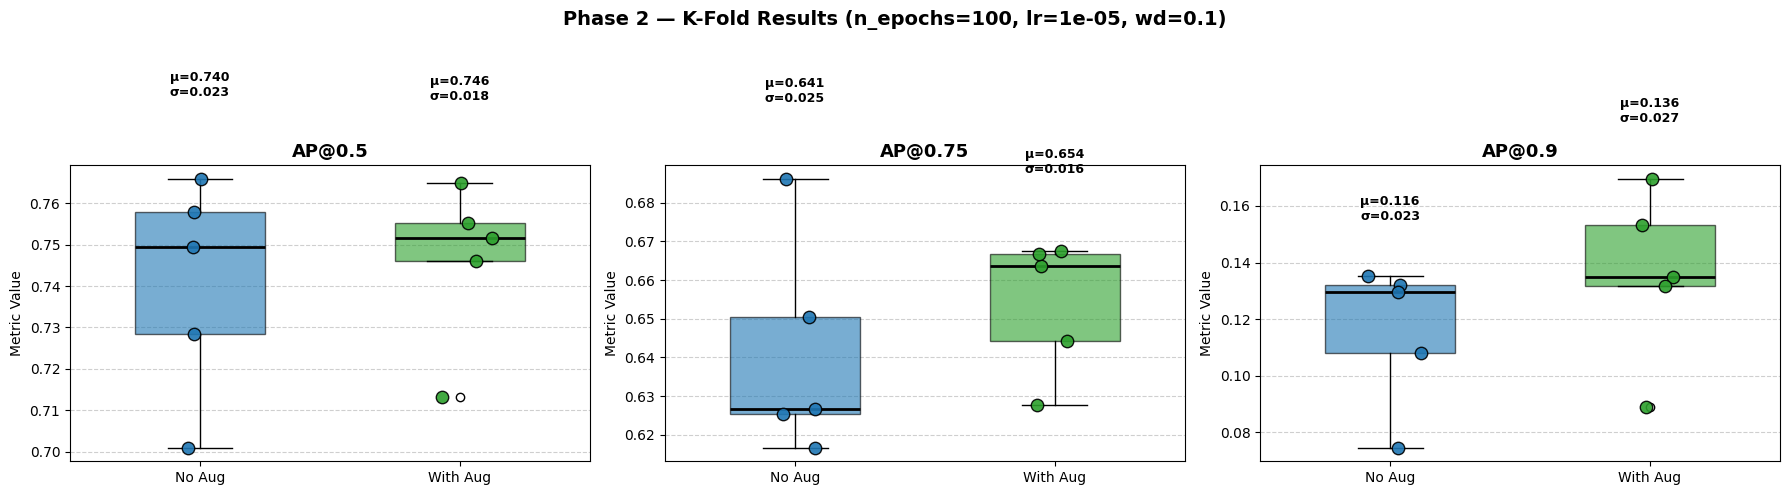

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ap_metrics = ['AP@0.5_AP', 'AP@0.75_AP', 'AP@0.9_AP']
titles = ['AP@0.5', 'AP@0.75', 'AP@0.9']

for ax, metric, title in zip(axes, ap_metrics, titles):
    data_a = df_A[metric].values
    data_b = df_B[metric].values

    bp = ax.boxplot([data_a, data_b],
                    labels=['No Aug', 'With Aug'],
                    patch_artist=True,
                    widths=0.5,
                    medianprops=dict(color='black', linewidth=2))

    bp['boxes'][0].set_facecolor('#1f77b4')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#2ca02c')
    bp['boxes'][1].set_alpha(0.6)

    x_a = np.random.normal(1, 0.05, size=len(data_a))
    x_b = np.random.normal(2, 0.05, size=len(data_b))
    ax.scatter(x_a, data_a, color='#1f77b4', edgecolor='black', s=80, zorder=3, alpha=0.9)
    ax.scatter(x_b, data_b, color='#2ca02c', edgecolor='black', s=80, zorder=3, alpha=0.9)

    ax.text(1, max(data_a) + 0.02, f"μ={data_a.mean():.3f}\nσ={data_a.std():.3f}",
            ha='center', fontweight='bold', fontsize=9)
    ax.text(2, max(data_b) + 0.02, f"μ={data_b.mean():.3f}\nσ={data_b.std():.3f}",
            ha='center', fontweight='bold', fontsize=9)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel("Metric Value")
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)

fig.suptitle(f"Phase 2 — K-Fold Results (n_epochs={N_EPOCHS}, lr={LEARNING_RATE}, wd={WEIGHT_DECAY})",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase2_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

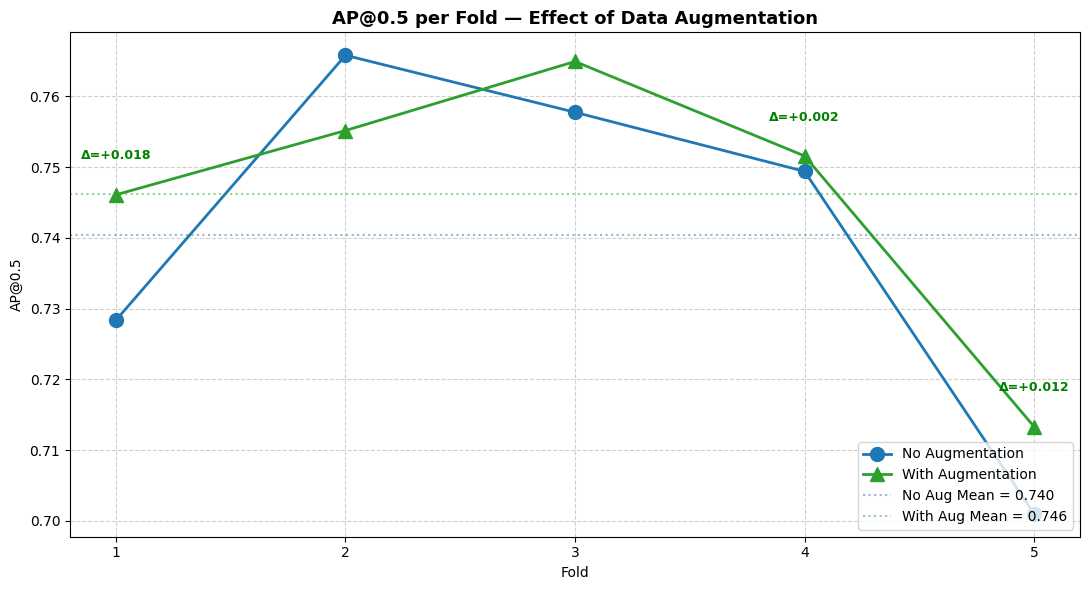

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

folds = df_A["fold"].values

ax.plot(folds, df_A["AP@0.5_AP"], marker='o', linewidth=2, markersize=10,
        color='#1f77b4', label='No Augmentation')
ax.plot(folds, df_B["AP@0.5_AP"], marker='^', linewidth=2, markersize=10,
        color='#2ca02c', label='With Augmentation')

for f in folds:
    y1 = df_A[df_A["fold"] == f]["AP@0.5_AP"].values[0]
    y2 = df_B[df_B["fold"] == f]["AP@0.5_AP"].values[0]
    delta = y2 - y1
    color_delta = 'green' if delta > 0 else 'red'
    ax.annotate(f"Δ={delta:+.3f}",
                xy=(f, max(y1, y2) + 0.005),
                ha='center', fontsize=9, color=color_delta, fontweight='bold')

ax.axhline(y=df_A["AP@0.5_AP"].mean(), color='#1f77b4', linestyle=':', alpha=0.5,
           label=f'No Aug Mean = {df_A["AP@0.5_AP"].mean():.3f}')
ax.axhline(y=df_B["AP@0.5_AP"].mean(), color='#2ca02c', linestyle=':', alpha=0.5,
           label=f'With Aug Mean = {df_B["AP@0.5_AP"].mean():.3f}')

ax.set_title("AP@0.5 per Fold — Effect of Data Augmentation", fontsize=13, fontweight='bold')
ax.set_xlabel("Fold")
ax.set_ylabel("AP@0.5")
ax.set_xticks(folds)
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase2_per_fold.png", dpi=150, bbox_inches='tight')
plt.show()

## 10. Per-Image Consolidation

In [ ]:
all_per_image_dfs = []

for exp_dir in EXPERIMENT_DIRS.values():
    per_image_dir = exp_dir / "per_image_metrics"
    for csv_file in sorted(per_image_dir.glob("*_per_image.csv")):
        df_tmp = pd.read_csv(csv_file)
        all_per_image_dfs.append(df_tmp)

if all_per_image_dfs:
    df_all_per_image = pd.concat(all_per_image_dfs, ignore_index=True)
    df_all_per_image = df_all_per_image.sort_values(["experiment", "fold", "image_name"]).reset_index(drop=True)

    per_image_consolidated = OUTPUT_DIR / "phase2_per_image_consolidated.csv"
    df_all_per_image.to_csv(per_image_consolidated, index=False)
    print(f"Per-image consolidated saved: {per_image_consolidated}")
    print(f"Shape: {df_all_per_image.shape}")
    df_all_per_image.head(20)

Per-image consolidated saved: /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase2_kfold_default_params/phase2_per_image_consolidated.csv
Shape: (52, 25)


## 11. Final Summary

In [ ]:
phase2_summary = {
    "config_used": {
        "n_epochs": N_EPOCHS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "batch_size": BATCH_SIZE,
        "augmentation_multiplier_when_used": AUGMENTATION_MULTIPLIER,
    },
    "experiment_A_no_aug": {
        "AP@0.5_mean": float(df_A["AP@0.5_AP"].mean()),
        "AP@0.5_std": float(df_A["AP@0.5_AP"].std()),
        "AP@0.75_mean": float(df_A["AP@0.75_AP"].mean()),
        "AP@0.75_std": float(df_A["AP@0.75_AP"].std()),
        "AP@0.9_mean": float(df_A["AP@0.9_AP"].mean()),
        "AP@0.9_std": float(df_A["AP@0.9_AP"].std()),
        "F1_mean": float(df_A["AP@0.5_F1"].mean()),
        "F1_std": float(df_A["AP@0.5_F1"].std()),
        "training_time_mean_s": float(df_A["training_time_s"].mean()),
    },
    "experiment_B_with_aug": {
        "AP@0.5_mean": float(df_B["AP@0.5_AP"].mean()),
        "AP@0.5_std": float(df_B["AP@0.5_AP"].std()),
        "AP@0.75_mean": float(df_B["AP@0.75_AP"].mean()),
        "AP@0.75_std": float(df_B["AP@0.75_AP"].std()),
        "AP@0.9_mean": float(df_B["AP@0.9_AP"].mean()),
        "AP@0.9_std": float(df_B["AP@0.9_AP"].std()),
        "F1_mean": float(df_B["AP@0.5_F1"].mean()),
        "F1_std": float(df_B["AP@0.5_F1"].std()),
        "training_time_mean_s": float(df_B["training_time_s"].mean()),
    },
    "augmentation_effect_AP@0.5": float(df_B["AP@0.5_AP"].mean() - df_A["AP@0.5_AP"].mean()),
}

with open(OUTPUT_DIR / "phase2_final_summary.json", "w") as f:
    json.dump(phase2_summary, f, indent=4)

print(json.dumps(phase2_summary, indent=2))

{
  "config_used": {
    "n_epochs": 100,
    "learning_rate": 1e-05,
    "weight_decay": 0.1,
    "batch_size": 1,
    "augmentation_multiplier_when_used": 2
  },
  "experiment_A_no_aug": {
    "AP@0.5_mean": 0.740467643737793,
    "AP@0.5_std": 0.026113289152107425,
    "AP@0.75_mean": 0.6410487294197083,
    "AP@0.75_std": 0.0281710811459312,
    "AP@0.9_mean": 0.11584369838237762,
    "AP@0.9_std": 0.02546050677840648,
    "F1_mean": 0.8490240191063105,
    "F1_std": 0.01398916302291562,
    "training_time_mean_s": 156.90163674354554
  },
  "experiment_B_with_aug": {
    "AP@0.5_mean": 0.746220588684082,
    "AP@0.5_std": 0.01964231181727272,
    "AP@0.75_mean": 0.653997826576233,
    "AP@0.75_std": 0.017456922582212424,
    "AP@0.9_mean": 0.1357425332069397,
    "AP@0.9_std": 0.030181412180618022,
    "F1_mean": 0.8540747359338008,
    "F1_std": 0.011973875836559653,
    "training_time_mean_s": 469.7578416347504
  },
  "augmentation_effect_AP@0.5": 0.005752944946289085
}
